In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

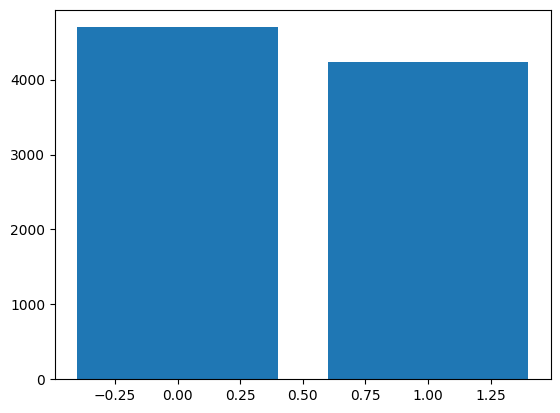

In [117]:
from sklearn.model_selection import train_test_split

train_df= pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")

X= train_df.drop(columns=['id','deposit'])
y= train_df['deposit']

X_train, X_eval, y_train, y_eval= train_test_split(X, y, train_size=0.8, stratify= y, random_state= seed)

X_test= test_df.drop(columns=['id'])

plt.bar(np.unique_counts(y).values, np.unique_counts(y).counts)
plt.show()

In [118]:
# Subtask 1

answer1=[]

deposit_rate = train_df.groupby('job')['deposit'].mean()

answer1.append({
    'subtaskID': 1,
    'datapointID': 1,
    'answer': deposit_rate.index[np.argmax(deposit_rate)]
})

answer1= pd.DataFrame(answer1)
answer1.head()

,subtaskID,datapointID,answer
0,1,1,student


In [119]:
# Subtask 2

answer2=[]

answer2.append({
    'subtaskID': 2,
    'datapointID': 1,
    'answer': train_df['month'].value_counts().index[0]
})

answer2= pd.DataFrame(answer2)
answer2.head()

,subtaskID,datapointID,answer
0,2,1,may


In [120]:
# Subtask 3

from catboost import CatBoostClassifier

cat_cols= X.select_dtypes(include=['object', 'string']).columns.to_list()

model= CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    eval_metric='TotalF1',
    early_stopping_rounds=200,
    auto_class_weights='Balanced',
    cat_features= cat_cols,
    random_state= seed,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_eval, y_eval)],
    verbose=200
)

predictions= model.predict(X_test)

answer3= []
for id_, pred in zip(test_df['id'], predictions):
    answer3.append({
    'subtaskID': 3,
    'datapointID': id_,
    'answer': pred
    })

answer3= pd.DataFrame(answer3)
answer3.head(5)

0:	learn: 0.7915362	test: 0.7566840	best: 0.7566840 (0)	total: 23.7ms	remaining: 1m 11s
200:	learn: 0.8674906	test: 0.8533879	best: 0.8533879 (193)	total: 3.76s	remaining: 52.3s
400:	learn: 0.8806050	test: 0.8618878	best: 0.8624241 (384)	total: 7.74s	remaining: 50.2s
600:	learn: 0.8944127	test: 0.8624746	best: 0.8636480 (527)	total: 11.8s	remaining: 47.1s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8636479739
bestIteration = 527

Shrink model to first 528 iterations.


,subtaskID,datapointID,answer
0,3,5686,0
1,3,5206,1
2,3,5160,0
3,3,5016,1
4,3,1297,1


In [121]:
# Subtask 4

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X_subtask4= StandardScaler().fit_transform(X_test.drop(columns=cat_cols))

model= KMeans(
    n_clusters=2,
    n_init=50,
    max_iter=1000,
    random_state= seed
)

predictions= model.fit_predict(X_subtask4)

answer4 =[]

for id_, pred in zip(test_df['id'], predictions):
    answer4.append({
    'subtaskID': 4,
    'datapointID': id_,
    'answer': pred
    })

answer4= pd.DataFrame(answer4)
answer4.head(5)

,subtaskID,datapointID,answer
0,4,5686,0
1,4,5206,0
2,4,5160,0
3,4,5016,0
4,4,1297,0


In [122]:
answer= pd.concat([answer1, answer2, answer3, answer4])
answer.to_csv("submission.csv", index= False)